# SmartCard : E-Commerce Website
## Create a Customer Clustering System

# Learning:
### pd.to_datatime( string, dayfirst=True)
### sns.pairplot(df[cols]), creates graph of one feature with all other features one by one in matrix

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# import sklearn.preprocessing

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [3]:
print(f"Shape : {df.shape}")
df.info

Shape : (2240, 22)


<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Pre-Processing:
### df["column_name"].fillna(value) : fills the missing values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].mean())
df["Income"].isnull().sum()

np.int64(0)

In [6]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference = df["Dt_Customer"].max()
print("Reference :", reference)

max_year = reference.year
print(f"Max Year : {max_year}")

df["Customer_Tenure_Days"] = ( reference - df["Dt_Customer"]).dt.days

Reference : 2014-06-29 00:00:00
Max Year : 2014


In [7]:
# Age
df["Age"] = max_year - df["Year_Birth"]

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,663,57
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,113,60
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,312,49
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,139,30
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,161,33


In [9]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Age,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,663,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,113,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,312,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,139,30,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,161,33,422


In [11]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [12]:
df["Education"] = df["Education"].replace({
    "2n Cycle": "Undergraduate",
    "Basic": "Undergraduate",
    "Graduation": "Graduate",
    "PhD": "Postgraduate",
    "Master": "Postgraduate"    
})

df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [13]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Customer_Tenure_Days', 'Age',
       'Total_Spending'],
      dtype='object')

In [14]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "YOLO":"Alone",
    "Absurd":"Alone"
})

df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Age,Total_Spending,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,663,57,1617,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,113,60,27,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,312,49,776,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,139,30,53,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,161,33,422,Partner


In [16]:
df.shape

(2240, 26)

In [17]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Customer_Tenure_Days', 'Age', 'Total_Spending',
       'Living_With'],
      dtype='object')

In [18]:
drop_cols = ["ID", "Year_Birth", "Marital_Status", "Dt_Customer", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df_cleaned = df.drop(columns=drop_cols)

In [19]:
df_cleaned.head()

,Education,Income,Kidhome,Teenhome,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_Days,Age,Total_Spending,Living_With
0,Graduate,58138.0,0,0,58,3,8,10,4,7,0,1,663,57,1617,Alone
1,Graduate,46344.0,1,1,38,2,1,1,2,5,0,0,113,60,27,Alone
2,Graduate,71613.0,0,0,26,1,8,2,10,4,0,0,312,49,776,Partner
3,Graduate,26646.0,1,0,26,2,2,0,4,6,0,0,139,30,53,Partner
4,Postgraduate,58293.0,1,0,94,5,5,3,6,5,0,0,161,33,422,Partner


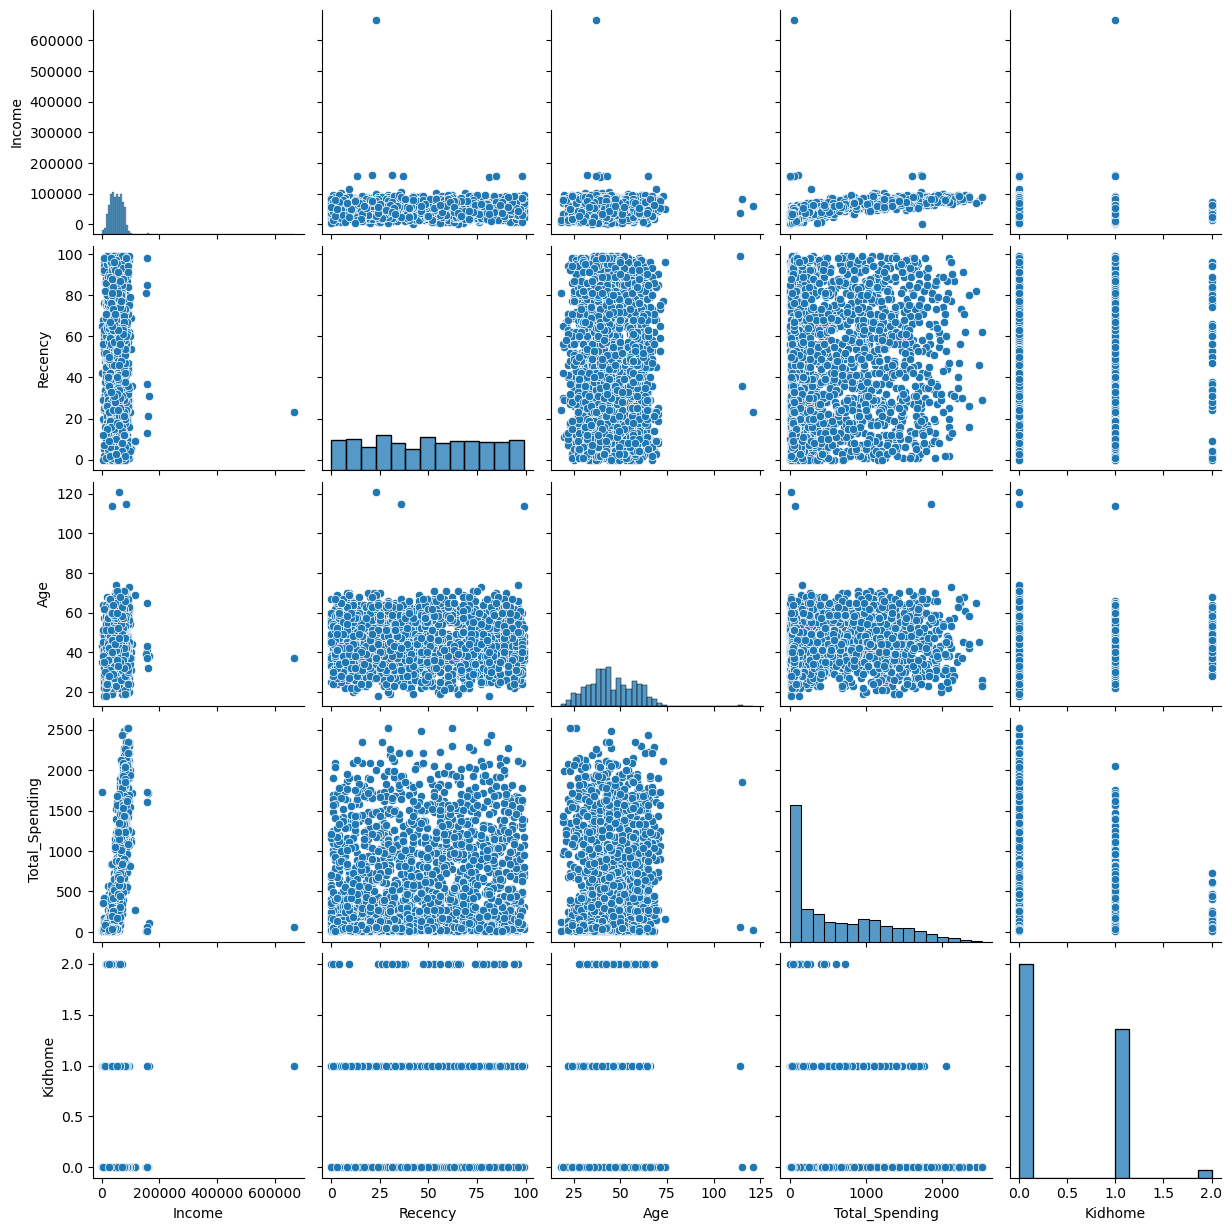

In [20]:
cols = [ "Income", "Recency", "Age", "Total_Spending", "Kidhome"]

# relative plots of some features - pair plots
sns.pairplot(df_cleaned[cols])

In [21]:
print(f"Dataset with outlier : {len(df_cleaned)}")

df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]
df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]

print(f"Dataset after outlier removal : {len(df_cleaned)}")


Dataset with outlier : 2240
Dataset after outlier removal : 2236


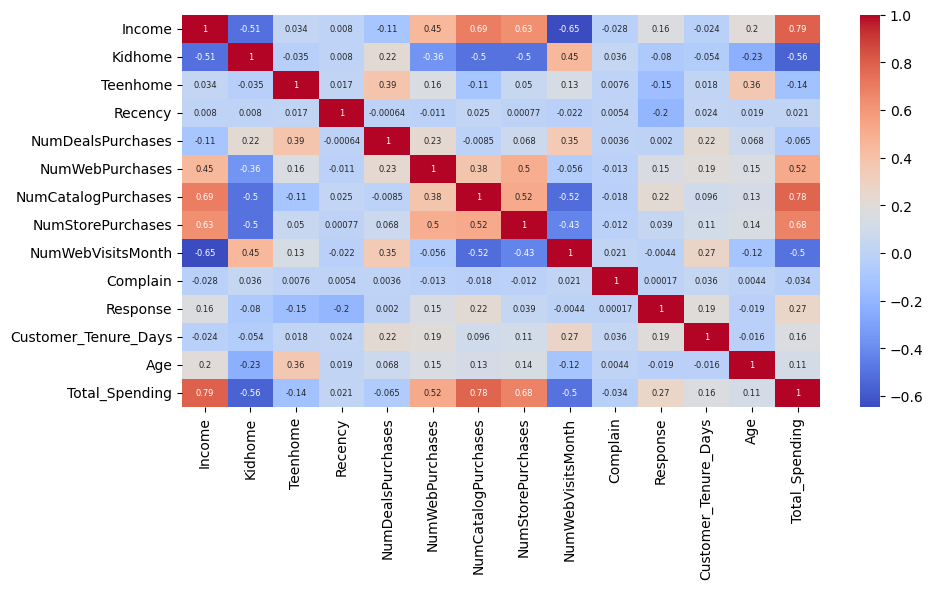

In [25]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm",
)

plt.tight_layout()